## 0. Imports e carregamento

> Certifique-se de ter rodado `02_nlp.ipynb` antes. Este notebook lê os dados já processados de `motor1_analise_final_clean.csv` e `tfidf_final_clean.csv`.

In [2]:
import json
import pathlib
import random
import re
import time
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import requests
import seaborn as sns
from bs4 import BeautifulSoup
from joblib import Parallel, delayed
from nltk.corpus import stopwords
from nltk.tokenize import wordpunct_tokenize
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    r2_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from unidecode import unidecode

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
CORES = sns.color_palette("muted")

print("Imports OK")

Imports OK


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Carrega dados processados pelo notebook 02_nlp
df = pd.read_csv("motor1_analise_final_clean.csv", encoding="utf-8-sig")
df_tfidf = pd.read_csv("tfidf_final_clean.csv", encoding="utf-8-sig")

# Reconstrói X_tfidf e vocab a partir do df_tfidf
vocab = df_tfidf.columns.tolist()
X_tfidf_arr = df_tfidf.values
X = X_tfidf_arr

# Compatibilidade com variáveis usadas nos blocos de análise
import scipy.sparse as sp
X_tfidf = sp.csr_matrix(X_tfidf_arr)

import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
CORES = sns.color_palette("muted")

print(f"Notícias carregadas: {len(df)}")
print(f"Features TF-IDF: {len(vocab)}")
df.head(3)


## 10. Classificação — Random Forest

In [18]:
le = LabelEncoder()
y = le.fit_transform(df["grupo"])
X = X_tfidf.toarray()

print("Classes:", le.classes_)
print("Distribuição:", dict(zip(le.classes_, np.bincount(y))))

contagem_y = np.bincount(y)
classes_validas = np.where(contagem_y >= 5)[0]
mask_valida = np.isin(y, classes_validas)

X_v = X[mask_valida]
y_v = y[mask_valida]

print(f"Amostras após filtro de classe mínima: {len(y_v)}")

Classes: ['Elétrico' 'Geral' 'Misto/Híbrido']
Distribuição: {'Elétrico': np.int64(60), 'Geral': np.int64(1), 'Misto/Híbrido': np.int64(129)}
Amostras após filtro de classe mínima: 189


In [19]:
X_tmp, X_teste, y_tmp, y_teste = train_test_split(
    X_v, y_v, test_size=0.2, random_state=42, stratify=y_v
)
X_treino, X_calib, y_treino, y_calib = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(f"Treino: {X_treino.shape[0]} | Calibração: {X_calib.shape[0]} | Teste: {X_teste.shape[0]}")

Treino: 113 | Calibração: 38 | Teste: 38


In [20]:
ns = [50, 100, 200, 300, 500]
resultados_calib = []

for n in ns:
    modelo = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    )
    modelo.fit(X_treino, y_treino)
    f1_c = f1_score(y_calib, modelo.predict(X_calib), average="macro", zero_division=0)
    resultados_calib.append({"n_estimators": n, "F1_macro_calib": f1_c})
    print(f"n={n:3d} -> F1-macro calib = {f1_c:.4f}")

df_calib = pd.DataFrame(resultados_calib)
melhor_n = int(df_calib.loc[df_calib["F1_macro_calib"].idxmax(), "n_estimators"])
print(f"Melhor n_estimators: {melhor_n}")
df_calib

n= 50 -> F1-macro calib = 0.8246
n=100 -> F1-macro calib = 0.7816
n=200 -> F1-macro calib = 0.7816
n=300 -> F1-macro calib = 0.7816
n=500 -> F1-macro calib = 0.7816
Melhor n_estimators: 50


,n_estimators,F1_macro_calib
0,50,0.824561
1,100,0.781609
2,200,0.781609
3,300,0.781609
4,500,0.781609


In [21]:
clf = RandomForestClassifier(
    n_estimators=melhor_n,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)
clf.fit(X_treino, y_treino)
y_pred = clf.predict(X_teste)

nomes_classes = le.classes_[[c for c in np.unique(y_v)]]

print("Métricas no conjunto de teste")
print(f"Acurácia : {accuracy_score(y_teste, y_pred):.4f}")
print(f"F1 Macro : {f1_score(y_teste, y_pred, average='macro', zero_division=0):.4f}")
print()
print(classification_report(y_teste, y_pred, target_names=nomes_classes, zero_division=0))

Métricas no conjunto de teste
Acurácia : 0.9211
F1 Macro : 0.9065

               precision    recall  f1-score   support

     Elétrico       0.91      0.83      0.87        12
Misto/Híbrido       0.93      0.96      0.94        26

     accuracy                           0.92        38
    macro avg       0.92      0.90      0.91        38
 weighted avg       0.92      0.92      0.92        38



In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_cv = cross_val_score(
    RandomForestClassifier(
        n_estimators=melhor_n,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    ),
    X_treino,
    y_treino,
    cv=cv,
    scoring="f1_macro",
)

print(f"Cross-val F1-macro: {scores_cv.mean():.4f} ± {scores_cv.std():.4f}")
print(f"Scores por fold: {[f'{s:.4f}' for s in scores_cv]}")

Cross-val F1-macro: 0.7376 ± 0.0636
Scores por fold: ['0.8392', '0.7745', '0.6618', '0.7270', '0.6857']


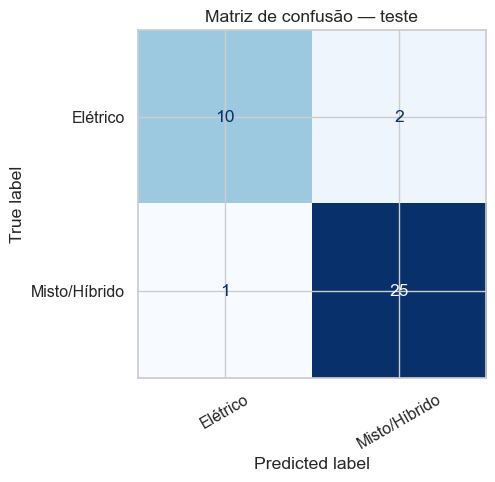

Salvo: fig_confusion_matrix_clean.png


In [23]:
cm = confusion_matrix(y_teste, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=nomes_classes)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=30)
ax.set_title("Matriz de confusão — teste")
plt.tight_layout()
plt.savefig("fig_confusion_matrix_clean.png", dpi=150, bbox_inches="tight")
plt.show()

print("Salvo: fig_confusion_matrix_clean.png")

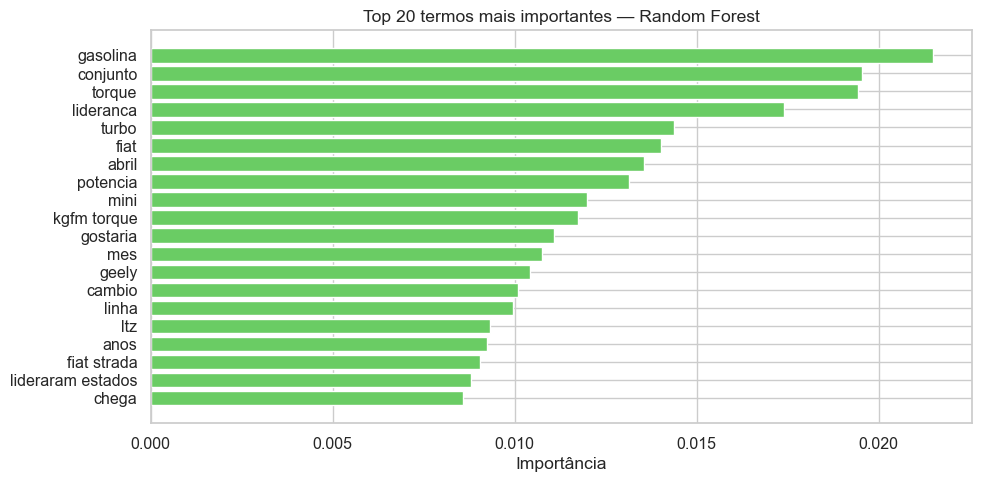

Salvo: fig_feature_importance_clean.png


In [24]:
importancias = pd.Series(clf.feature_importances_, index=vocab)
top_imp = importancias.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_imp.index[::-1], top_imp.values[::-1], color=CORES[2])
ax.set_title("Top 20 termos mais importantes — Random Forest")
ax.set_xlabel("Importância")
plt.tight_layout()
plt.savefig("fig_feature_importance_clean.png", dpi=150, bbox_inches="tight")
plt.show()

print("Salvo: fig_feature_importance_clean.png")

## 11. Regressão — volume lexical

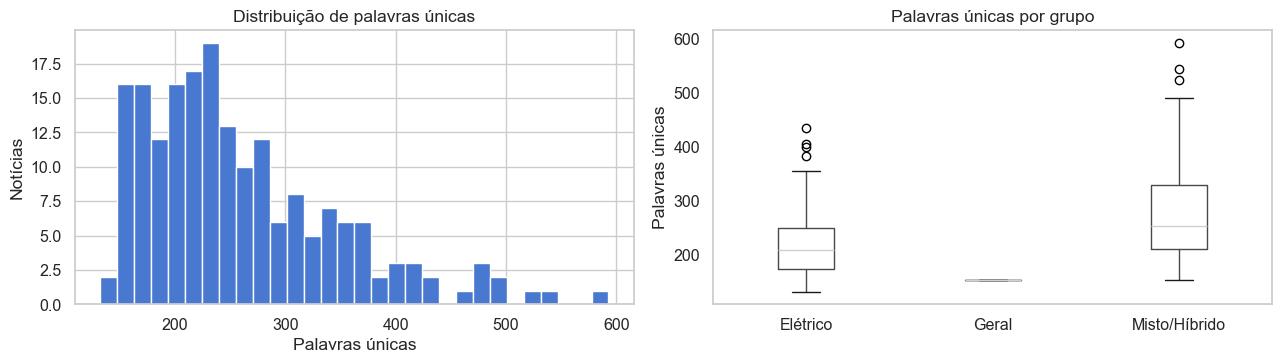

In [25]:
y_reg = df["n_unicos"].values
X_reg = X

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_reg, bins=30, color=CORES[0], edgecolor="white")
axes[0].set_title("Distribuição de palavras únicas")
axes[0].set_xlabel("Palavras únicas")
axes[0].set_ylabel("Notícias")

df.boxplot(column="n_unicos", by="grupo", ax=axes[1], grid=False)
axes[1].set_title("Palavras únicas por grupo")
axes[1].set_xlabel("")
axes[1].set_ylabel("Palavras únicas")
plt.suptitle("")

plt.tight_layout()
plt.show()

In [26]:
X_tmp_r, X_teste_r, y_tmp_r, y_teste_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
X_treino_r, X_calib_r, y_treino_r, y_calib_r = train_test_split(
    X_tmp_r, y_tmp_r, test_size=0.25, random_state=42
)

ns_reg = [50, 100, 200, 400]
modelos_reg = {}
resultados_reg = []

for n in ns_reg:
    modelo = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    modelo.fit(X_treino_r, y_treino_r)
    mae = mean_absolute_error(y_calib_r, modelo.predict(X_calib_r))
    resultados_reg.append({"n_estimators": n, "MAE_calib": mae})
    modelos_reg[n] = modelo
    print(f"n={n:3d} -> MAE calib = {mae:.2f}")

df_reg = pd.DataFrame(resultados_reg)
melhor_n_reg = int(df_reg.loc[df_reg["MAE_calib"].idxmin(), "n_estimators"])
print(f"Melhor n_estimators: {melhor_n_reg}")

pred_r = modelos_reg[melhor_n_reg].predict(X_teste_r)
mae_teste = mean_absolute_error(y_teste_r, pred_r)
r2_teste = r2_score(y_teste_r, pred_r)

print(f"MAE no teste: {mae_teste:.2f} palavras")
print(f"R² no teste : {r2_teste:.4f}")

n= 50 -> MAE calib = 36.22
n=100 -> MAE calib = 36.14
n=200 -> MAE calib = 36.69
n=400 -> MAE calib = 36.48
Melhor n_estimators: 100
MAE no teste: 40.98 palavras
R² no teste : 0.6128


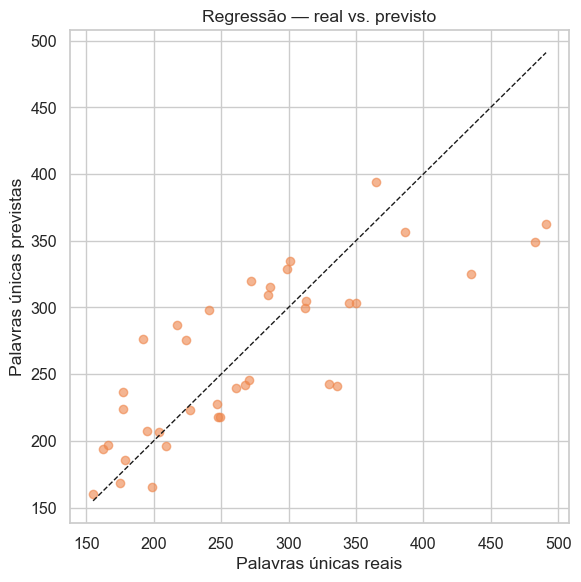

,real,previsto
0,155,160.2
1,435,324.8
2,177,236.5
3,224,275.7
4,227,223.1
5,261,239.7
6,301,335.1
7,271,245.7
8,286,315.2
9,299,329.0


In [27]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_teste_r, pred_r, alpha=0.6, color=CORES[1])

limite_min = min(y_teste_r.min(), pred_r.min())
limite_max = max(y_teste_r.max(), pred_r.max())
ax.plot([limite_min, limite_max], [limite_min, limite_max], "k--", linewidth=1)

ax.set_title("Regressão — real vs. previsto")
ax.set_xlabel("Palavras únicas reais")
ax.set_ylabel("Palavras únicas previstas")
plt.tight_layout()
plt.show()

pd.DataFrame({"real": y_teste_r, "previsto": pred_r.round(1)}).head(10)

## 12. Exportação final

In [28]:
colunas = [
    "url", "titulo", "descricao", "categoria", "data", "grupo",
    "texto_limpo", "n_tokens", "n_unicos",
]

df[colunas].to_csv("motor1_analise_final_clean.csv", index=False, encoding="utf-8-sig")
df_tfidf.to_csv("tfidf_final_clean.csv", index=False, encoding="utf-8-sig")

sumario = df.groupby("grupo").agg(
    n_noticias=("titulo", "count"),
    media_tokens=("n_tokens", "mean"),
    media_unicos=("n_unicos", "mean"),
    mediana_tokens=("n_tokens", "median"),
).round(1)
sumario.to_csv("sumario_grupos_clean.csv", encoding="utf-8-sig")

print("Arquivos exportados:")
print("  motor1_analise_final_clean.csv")
print("  tfidf_final_clean.csv")
print("  sumario_grupos_clean.csv")
print()
print(sumario)

Arquivos exportados:
  motor1_analise_final_clean.csv
  tfidf_final_clean.csv
  sumario_grupos_clean.csv

               n_noticias  media_tokens  media_unicos  mediana_tokens
grupo                                                                
Elétrico               60         296.2         226.3           268.5
Geral                   1         183.0         153.0           183.0
Misto/Híbrido         129         365.7         277.0           334.0


## 13. Conclusões

Preencha após rodar o notebook:

| Métrica | Valor |
|---|---|
| Total de notícias | |
| Grupo mais frequente | |
| Classificador — acurácia | |
| Classificador — F1 macro | |
| Regressão — MAE | |
| Regressão — R² | |

Pontos para interpretar:

- Os grupos formam clusters visíveis no t-SNE?
- Quais termos diferenciam notícias sobre elétricos, combustão e híbridos?
- Qual grupo tem maior volume lexical médio?
- Quais marcas aparecem mais nas notícias coletadas?